In [10]:
#Import Packages
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 50)
pd.set_option('display.float_format', '{:,.2f}'.format)

print('Libraries loaded successfully!')

Libraries loaded successfully!


## IPUMS - Employed_Only

In [11]:
# Load IPUMS dataset
ipums_path = os.path.expanduser('~/repoad688-employability-sum26-groupB/data/processed/employed_only.csv')
ipums = pd.read_csv(ipums_path)
print(f'Shape: {ipums.shape}')
print(f'\nColumns: {ipums.columns.tolist()}')
ipums.head(10)

Shape: (1572726, 13)

Columns: ['SERIAL', 'PERNUM', 'SEX', 'AGE', 'RACE', 'STATEFIP', 'OCC', 'IND', 'INCWAGE', 'PERWT', 'SEX_LABEL', 'RACE_LABEL', 'STATE_NAME']


,SERIAL,PERNUM,SEX,AGE,RACE,STATEFIP,OCC,IND,INCWAGE,PERWT,SEX_LABEL,RACE_LABEL,STATE_NAME
0,3800,1,1,64,1,1,8990,570,28000,11.00,Male,White,Alabama
1,3800,2,2,52,1,1,5740,8191,28000,12.00,Female,White,Alabama
2,3800,4,2,26,1,1,9141,6180,35200,15.00,Female,White,Alabama
3,3803,1,1,64,1,1,1010,9480,130000,199.00,Male,White,Alabama
4,3803,3,1,34,1,1,7240,7190,29100,208.00,Male,White,Alabama
5,3804,1,1,36,1,1,8140,2870,100000,69.00,Male,White,Alabama
6,3804,2,2,34,1,1,3500,8191,80000,65.00,Female,White,Alabama
7,3806,1,2,42,8,1,735,8290,150000,373.00,Female,Two races,Alabama
8,3807,1,2,37,1,1,2205,7870,15000,73.00,Female,White,Alabama
9,3807,2,1,41,2,1,5550,6370,73000,101.00,Male,Black,Alabama


In [12]:
# Summary Statustics
print('Summary Statistics:')
ipums.describe(include='all')

Summary Statistics:


,SERIAL,PERNUM,SEX,AGE,RACE,STATEFIP,OCC,IND,INCWAGE,PERWT,SEX_LABEL,RACE_LABEL,STATE_NAME
count,"1,572,726.00","1,572,726.00","1,572,726.00","1,572,726.00","1,572,726.00","1,572,726.00","1,572,726.00","1,572,726.00","1,572,726.00","1,572,726.00",1572726,1572726,1572726
unique,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2,9,51
top,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Male,White,California
freq,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,814215,1055852,183678
mean,"767,369.28",1.72,1.48,44.15,2.55,27.85,"3,909.96","6,393.94","68,391.03",106.07,NaN,NaN,NaN
std,"443,671.76",1.00,0.50,15.04,2.61,16.09,"2,710.91","2,599.67","82,490.59",94.82,NaN,NaN,NaN
min,"3,800.00",1.00,1.00,16.00,1.00,1.00,10.00,170.00,0.00,1.00,NaN,NaN,NaN
25%,"377,769.25",1.00,1.00,32.00,1.00,12.00,"1,555.00","4,971.00","24,000.00",52.00,NaN,NaN,NaN
50%,"760,904.50",1.00,1.00,44.00,1.00,27.00,"3,910.00","7,380.00","50,000.00",78.00,NaN,NaN,NaN
75%,"1,159,119.75",2.00,2.00,56.00,3.00,42.00,"5,510.00","8,191.00","85,000.00",126.00,NaN,NaN,NaN


In [13]:
# Handle missing values
missing = ipums.isnull().sum()
missing_pct = (missing / len(ipums) * 100).round(2)
missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct
}).query('`Missing Count` > 0').sort_values('Missing %', ascending=False)
print(f'Columns with missing values: {len(missing_df)} of {ipums.shape[1]}')
missing_df

Columns with missing values: 0 of 13


,Missing Count,Missing %


### Wage Gap by Gender

In [14]:
# Gender Distribution
print('Gender Distribution:')
print(ipums['SEX_LABEL'].value_counts())
print()
print('Gender % Distribution:')
print((ipums['SEX_LABEL'].value_counts(normalize=True) * 100).round(2))

Gender Distribution:
SEX_LABEL
Male      814215
Female    758511
Name: count, dtype: int64

Gender % Distribution:
SEX_LABEL
Male     51.77
Female   48.23
Name: proportion, dtype: float64


In [15]:
# Breakdown of $0 wage
zero_wage = ipums[ipums['INCWAGE'] == 0]
print(f'Records with $0 wage: {len(zero_wage):,}')
print(f'Percentage: {(len(zero_wage) / len(ipums) * 100):.2f}%')
print()
print('Gender breakdown of $0 wage:')
print(zero_wage['SEX_LABEL'].value_counts())

Records with $0 wage: 85,178
Percentage: 5.42%

Gender breakdown of $0 wage:
SEX_LABEL
Male      49117
Female    36061
Name: count, dtype: int64


In [16]:
print('Average wage INCLUDING $0:')
print(ipums.groupby('SEX_LABEL')['INCWAGE'].mean().round(2))

print('\nAverage wage EXCLUDING $0:')
ipums_nonzero = ipums[ipums['INCWAGE'] > 0]
print(ipums_nonzero.groupby('SEX_LABEL')['INCWAGE'].mean().round(2))
print(f'\nRows remaining after removing $0: {len(ipums_nonzero):,}')

Average wage INCLUDING $0:


SEX_LABEL
Female   56,730.36
Male     79,253.95
Name: INCWAGE, dtype: float64

Average wage EXCLUDING $0:
SEX_LABEL
Female   59,562.05
Male     84,341.82
Name: INCWAGE, dtype: float64

Rows remaining after removing $0: 1,487,548


In [17]:
# Remove $0 wage (outliers)
ipums_clean = ipums[ipums['INCWAGE'] > 0].copy()
print(f'Clean dataset shape: {ipums_clean.shape}')
print(f'Removed {len(ipums) - len(ipums_clean):,} rows with $0 wage')

Clean dataset shape: (1487548, 13)
Removed 85,178 rows with $0 wage


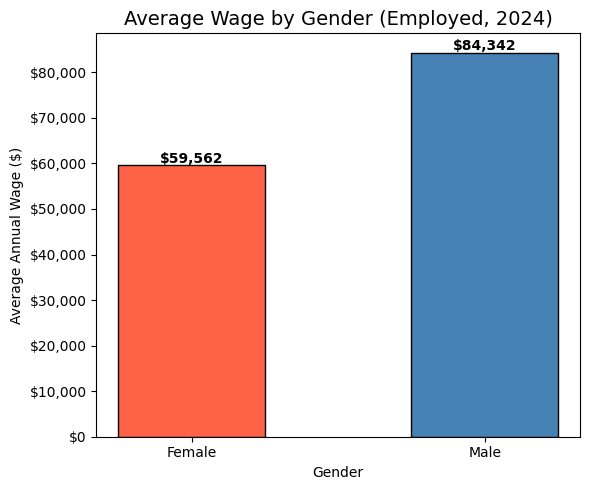

In [18]:
# Visulaize wage gap by gender
avg_wage = ipums_clean.groupby('SEX_LABEL')['INCWAGE'].mean().reset_index()

fig, ax = plt.subplots(figsize=(6, 5))
bars = ax.bar(avg_wage['SEX_LABEL'], avg_wage['INCWAGE'],
              color=['tomato', 'steelblue'], edgecolor='black', width=0.5)

ax.set_title('Average Wage by Gender (Employed, 2024)', fontsize=14)
ax.set_xlabel('Gender')
ax.set_ylabel('Average Annual Wage ($)')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))

for bar, val in zip(bars, avg_wage['INCWAGE']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 500,
            f'${val:,.0f}', ha='center', fontweight='bold')

plt.tight_layout()
plt.show()

In [19]:
#
clean_path = os.path.expanduser('~/repoad688-employability-sum26-groupB/data/clean/')
os.makedirs(clean_path, exist_ok=True)

output_path = f'{clean_path}employed_only_clean.csv'
ipums_clean.to_csv(output_path, index=False)
print(f'Saved to: {output_path}')
print(f'Shape: {ipums_clean.shape}')

Saved to: /home/ubuntu/repoad688-employability-sum26-groupB/data/clean/employed_only_clean.csv
Shape: (1487548, 13)


### Wage Gap by State

In [20]:
# Wage gap by state
state_wage = ipums_clean.groupby(['STATE_NAME', 'SEX_LABEL'])['INCWAGE'].mean().unstack()
state_wage['GAP'] = state_wage['Male'] - state_wage['Female']
state_wage['WOMEN_PCT'] = (state_wage['Female'] / state_wage['Male'] * 100).round(1)
state_wage = state_wage.sort_values('GAP', ascending=False)

print('Top 10 states with largest wage gap:')
state_wage.head(10)

Top 10 states with largest wage gap:


SEX_LABEL,Female,Male,GAP,WOMEN_PCT
STATE_NAME,,,,
Connecticut,"73,135.46","108,040.98","34,905.52",67.70
Utah,"47,738.95","82,223.48","34,484.53",58.10
New Jersey,"72,106.40","106,257.29","34,150.88",67.90
Washington,"70,533.68","102,560.63","32,026.96",68.80
Massachusetts,"75,958.91","106,280.88","30,321.97",71.50
District of Columbia,"111,588.14","141,154.05","29,565.91",79.10
Texas,"55,949.30","84,475.07","28,525.77",66.20
Louisiana,"46,693.61","74,387.98","27,694.37",62.80
Colorado,"66,938.28","94,510.71","27,572.44",70.80


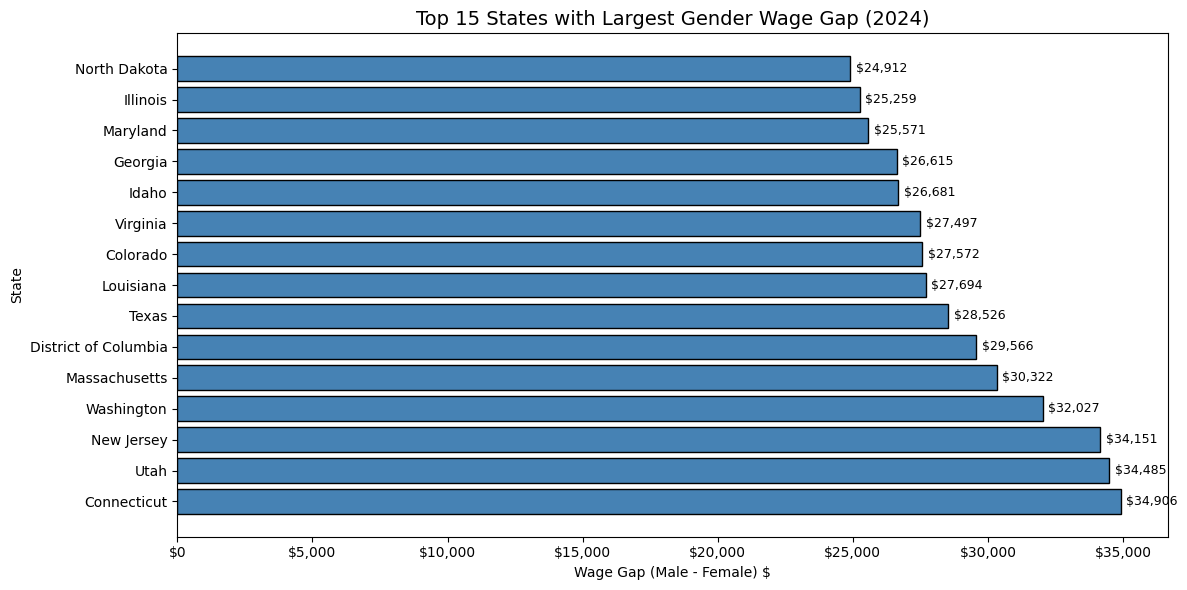

In [21]:
# Top 15 states with largest wage gap
top15 = state_wage.head(15)

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(top15.index, top15['GAP'], color='steelblue', edgecolor='black')

ax.set_title('Top 15 States with Largest Gender Wage Gap (2024)', fontsize=14)
ax.set_xlabel('Wage Gap (Male - Female) $')
ax.set_ylabel('State')
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))

for bar, val in zip(bars, top15['GAP']):
    ax.text(bar.get_width() + 200, bar.get_y() + bar.get_height()/2,
            f'${val:,.0f}', va='center', fontsize=9)

plt.tight_layout()
plt.show()

# Lightcast - Occupation

In [22]:
lc_occ = pd.read_csv('/home/ubuntu/repoad688-employability-sum26-groupB/data/processed/lightcast_occupation.csv')
print(f'Shape: {lc_occ.shape}')
print(f'Columns: {lc_occ.columns.tolist()}')
lc_occ.head(10)

Shape: (72498, 12)
Columns: ['ID', 'SOC_2', 'SOC_2_NAME', 'SOC_5', 'SOC_5_NAME', 'ONET', 'ONET_NAME', 'LOT_CAREER_AREA_NAME', 'LOT_V6_CAREER_AREA', 'LOT_V6_CAREER_AREA_NAME', 'LOT_V6_OCCUPATION_GROUP', 'LOT_V6_OCCUPATION_GROUP_NAME']


,ID,SOC_2,SOC_2_NAME,SOC_5,SOC_5_NAME,ONET,ONET_NAME,LOT_CAREER_AREA_NAME,LOT_V6_CAREER_AREA,LOT_V6_CAREER_AREA_NAME,LOT_V6_OCCUPATION_GROUP,LOT_V6_OCCUPATION_GROUP_NAME
0,1f57d95acf4dc67ed2819eb12f049f6a5c11782c,15-0000,Computer and Mathematical Occupations,15-2051,Data Scientists,15-2051.01,Business Intelligence Analysts,Information Technology and Computer Science,23.00,Information Technology and Computer Science,"2,310.00",Business Intelligence
1,0cb072af26757b6c4ea9464472a50a443af681ac,15-0000,Computer and Mathematical Occupations,15-2051,Data Scientists,15-2051.01,Business Intelligence Analysts,Information Technology and Computer Science,23.00,Information Technology and Computer Science,"2,310.00",Business Intelligence
2,85318b12b3331fa490d32ad014379df01855c557,15-0000,Computer and Mathematical Occupations,15-2051,Data Scientists,15-2051.01,Business Intelligence Analysts,Information Technology and Computer Science,23.00,Information Technology and Computer Science,"2,311.00",Data Analysis and Mathematics
3,1b5c3941e54a1889ef4f8ae55b401a550708a310,15-0000,Computer and Mathematical Occupations,15-2051,Data Scientists,15-2051.01,Business Intelligence Analysts,Information Technology and Computer Science,23.00,Information Technology and Computer Science,"2,311.00",Data Analysis and Mathematics
4,cb5ca25f02bdf25c13edfede7931508bfd9e858f,15-0000,Computer and Mathematical Occupations,15-2051,Data Scientists,15-2051.01,Business Intelligence Analysts,Information Technology and Computer Science,23.00,Information Technology and Computer Science,"2,310.00",Business Intelligence
5,35a6cd2183d9fb270e3f504b270f36d43cb759a6,15-0000,Computer and Mathematical Occupations,15-2051,Data Scientists,15-2051.01,Business Intelligence Analysts,Information Technology and Computer Science,23.00,Information Technology and Computer Science,"2,311.00",Data Analysis and Mathematics
6,06de8d192f30b1d8d3c575d453faf143d332f4d4,15-0000,Computer and Mathematical Occupations,15-2051,Data Scientists,15-2051.01,Business Intelligence Analysts,Information Technology and Computer Science,23.00,Information Technology and Computer Science,"2,311.00",Data Analysis and Mathematics
7,3d589c9d84677ca9468a5bc82295456e0ce6b13f,15-0000,Computer and Mathematical Occupations,15-2051,Data Scientists,15-2051.01,Business Intelligence Analysts,Information Technology and Computer Science,23.00,Information Technology and Computer Science,"2,311.00",Data Analysis and Mathematics
8,5a843df632e1ff756fa19d80a0871262d51becc0,15-0000,Computer and Mathematical Occupations,15-2051,Data Scientists,15-2051.01,Business Intelligence Analysts,Information Technology and Computer Science,23.00,Information Technology and Computer Science,"2,310.00",Business Intelligence
9,229620073766234e814e8add21db7dfaef69b3bd,15-0000,Computer and Mathematical Occupations,15-2051,Data Scientists,15-2051.01,Business Intelligence Analysts,Information Technology and Computer Science,23.00,Information Technology and Computer Science,"2,311.00",Data Analysis and Mathematics


In [23]:
# Check unique values in each column
print(f'Shape: {lc_occ.shape}')
print(f'\nUnique values per column:')
for col in lc_occ.columns:
    print(f'  {col}: {lc_occ[col].nunique()} unique values')

Shape: (72498, 12)

Unique values per column:
  ID: 72476 unique values
  SOC_2: 1 unique values
  SOC_2_NAME: 1 unique values
  SOC_5: 1 unique values
  SOC_5_NAME: 1 unique values
  ONET: 1 unique values
  ONET_NAME: 1 unique values
  LOT_CAREER_AREA_NAME: 4 unique values
  LOT_V6_CAREER_AREA: 4 unique values
  LOT_V6_CAREER_AREA_NAME: 4 unique values
  LOT_V6_OCCUPATION_GROUP: 6 unique values
  LOT_V6_OCCUPATION_GROUP_NAME: 6 unique values


In [24]:
print('LOT_V6_CAREER_AREA_NAME values:')
print(lc_occ['LOT_V6_CAREER_AREA_NAME'].value_counts())

print('\nLOT_V6_OCCUPATION_GROUP_NAME values:')
print(lc_occ['LOT_V6_OCCUPATION_GROUP_NAME'].value_counts())

LOT_V6_CAREER_AREA_NAME values:
LOT_V6_CAREER_AREA_NAME
Information Technology and Computer Science    67714
Business Management and Operations              4326
Healthcare                                       261
Marketing and Public Relations                   153
Name: count, dtype: int64

LOT_V6_OCCUPATION_GROUP_NAME values:
LOT_V6_OCCUPATION_GROUP_NAME
Data Analysis and Mathematics      30057
Business Intelligence              29445
Network and Systems Engineering     8212
Business Analysis                   4326
Health IT Professionals              261
Marketing Specialists                153
Name: count, dtype: int64


In [25]:
# Missing values check
missing = lc_occ.isnull().sum()
missing_pct = (missing / len(lc_occ) * 100).round(2)
missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing %': missing_pct
}).query('`Missing Count` > 0').sort_values('Missing %', ascending=False)
print(f'Columns with missing values: {len(missing_df)}')
missing_df

Columns with missing values: 12


,Missing Count,Missing %
SOC_2,44,0.06
SOC_2_NAME,44,0.06
SOC_5,44,0.06
SOC_5_NAME,44,0.06
LOT_V6_CAREER_AREA,44,0.06
ONET,44,0.06
ONET_NAME,44,0.06
LOT_CAREER_AREA_NAME,44,0.06
LOT_V6_OCCUPATION_GROUP,44,0.06
LOT_V6_CAREER_AREA_NAME,44,0.06


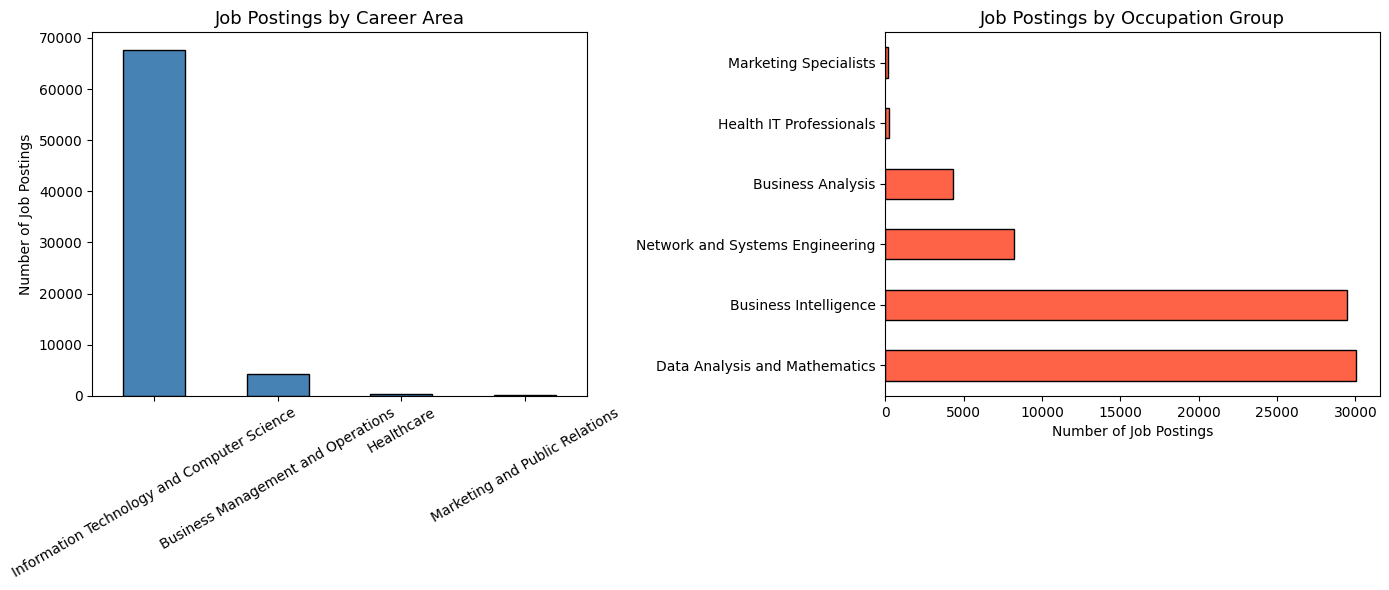

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Career Area Distribution
lc_occ['LOT_V6_CAREER_AREA_NAME'].value_counts().plot(
    kind='bar', ax=axes[0], color='steelblue', edgecolor='black'
)
axes[0].set_title('Job Postings by Career Area', fontsize=13)
axes[0].set_xlabel('')
axes[0].set_ylabel('Number of Job Postings')
axes[0].tick_params(axis='x', rotation=30)

# Occupation Group Distribution
lc_occ['LOT_V6_OCCUPATION_GROUP_NAME'].value_counts().plot(
    kind='barh', ax=axes[1], color='tomato', edgecolor='black'
)
axes[1].set_title('Job Postings by Occupation Group', fontsize=13)
axes[1].set_xlabel('Number of Job Postings')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

In [27]:
# Check IPUMS occupation codes
print('IPUMS OCC unique values (sample):')
print(ipums_clean['OCC'].value_counts().head(10))

print('\nIPUMS IND unique values (sample):')
print(ipums_clean['IND'].value_counts().head(10))

IPUMS OCC unique values (sample):
OCC
440     46012
3255    36057
2310    33012
9130    32485
4760    26229
5240    25850
4700    24816
4720    24771
9620    21864
1021    21455
Name: count, dtype: int64

IPUMS IND unique values (sample):
IND
7860    103993
770      90352
8191     77036
8680     74524
7870     43014
7380     37305
9470     28609
5392     27857
4971     24642
8090     23417
Name: count, dtype: int64


In [28]:
# Check Lightcast SOC codes
print('Lightcast SOC_5 unique values:')
print(lc_occ['SOC_5'].value_counts())

print('\nLightcast LOT_V6_OCCUPATION_GROUP_NAME:')
print(lc_occ['LOT_V6_OCCUPATION_GROUP_NAME'].value_counts())

Lightcast SOC_5 unique values:
SOC_5
15-2051    72454
Name: count, dtype: int64

Lightcast LOT_V6_OCCUPATION_GROUP_NAME:
LOT_V6_OCCUPATION_GROUP_NAME
Data Analysis and Mathematics      30057
Business Intelligence              29445
Network and Systems Engineering     8212
Business Analysis                   4326
Health IT Professionals              261
Marketing Specialists                153
Name: count, dtype: int64


In [29]:
# IT-related OCC codes in IPUMS are typically 1000-1999
ipums_it = ipums_clean[(ipums_clean['OCC'] >= 1000) & (ipums_clean['OCC'] <= 1999)]
print(f'IT workers in IPUMS: {len(ipums_it):,}')
print(f'\nGender distribution in IT:')
print(ipums_it['SEX_LABEL'].value_counts())
print(f'\nGender % in IT:')
print((ipums_it['SEX_LABEL'].value_counts(normalize=True) * 100).round(2))
print(f'\nAverage wage by gender in IT:')
print(ipums_it.groupby('SEX_LABEL')['INCWAGE'].mean().round(2))

IT workers in IPUMS: 119,994

Gender distribution in IT:
SEX_LABEL
Male      86895
Female    33099
Name: count, dtype: int64

Gender % in IT:
SEX_LABEL
Male     72.42
Female   27.58
Name: proportion, dtype: float64

Average wage by gender in IT:
SEX_LABEL
Female    96,397.65
Male     119,699.34
Name: INCWAGE, dtype: float64


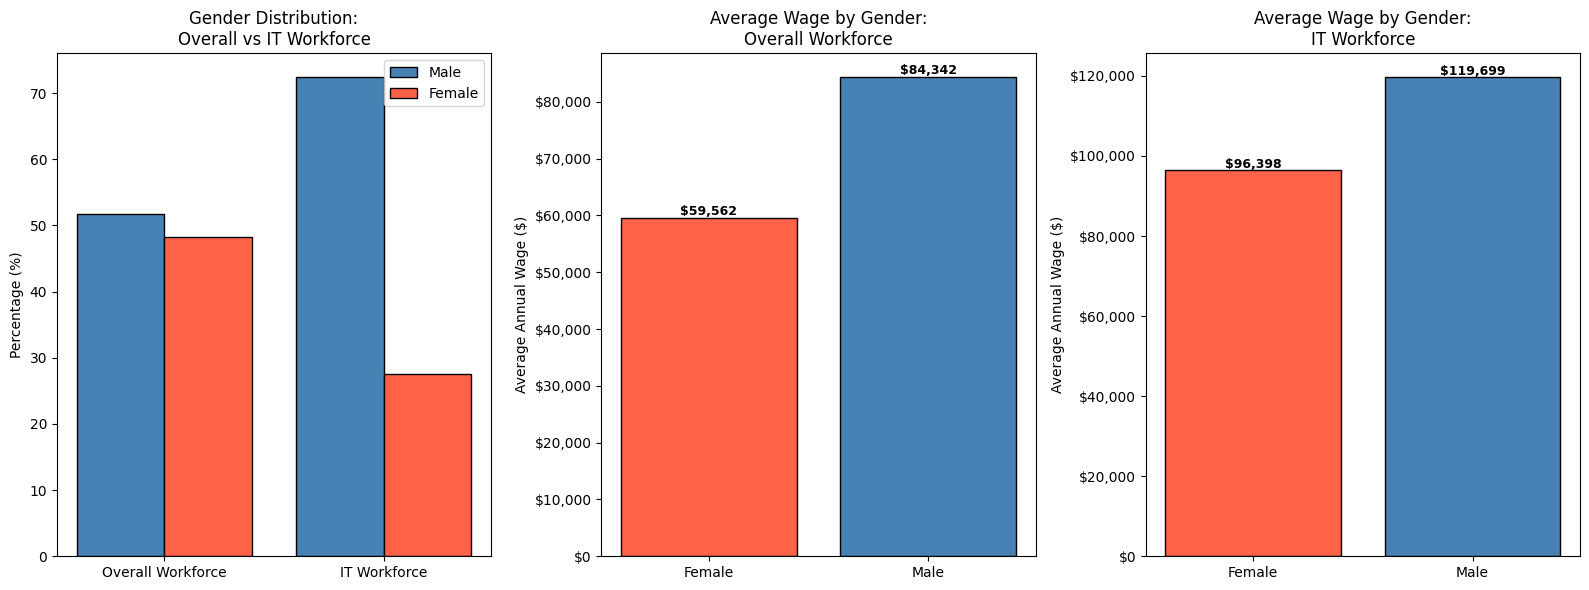

In [30]:
# Compare IT vs Overall workforce gender gap
fig, axes = plt.subplots(1, 3, figsize=(16, 6))

# Chart 1: Gender distribution - Overall vs IT
categories = ['Overall Workforce', 'IT Workforce']
male_pct = [51.77, 72.42]
female_pct = [48.23, 27.58]

x = range(len(categories))
axes[0].bar(x, male_pct, width=0.4, label='Male', color='steelblue', edgecolor='black')
axes[0].bar([i + 0.4 for i in x], female_pct, width=0.4, label='Female', color='tomato', edgecolor='black')
axes[0].set_title('Gender Distribution:\nOverall vs IT Workforce', fontsize=12)
axes[0].set_ylabel('Percentage (%)')
axes[0].set_xticks([i + 0.2 for i in x])
axes[0].set_xticklabels(categories)
axes[0].legend()

# Chart 2: Average wage by gender - Overall
avg_overall = ipums_clean.groupby('SEX_LABEL')['INCWAGE'].mean()
axes[1].bar(avg_overall.index, avg_overall.values, color=['tomato', 'steelblue'], edgecolor='black')
axes[1].set_title('Average Wage by Gender:\nOverall Workforce', fontsize=12)
axes[1].set_ylabel('Average Annual Wage ($)')
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
for i, v in enumerate(avg_overall.values):
    axes[1].text(i, v + 500, f'${v:,.0f}', ha='center', fontweight='bold', fontsize=9)

# Chart 3: Average wage by gender - IT
avg_it = ipums_it.groupby('SEX_LABEL')['INCWAGE'].mean()
axes[2].bar(avg_it.index, avg_it.values, color=['tomato', 'steelblue'], edgecolor='black')
axes[2].set_title('Average Wage by Gender:\nIT Workforce', fontsize=12)
axes[2].set_ylabel('Average Annual Wage ($)')
axes[2].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
for i, v in enumerate(avg_it.values):
    axes[2].text(i, v + 500, f'${v:,.0f}', ha='center', fontweight='bold', fontsize=9)

plt.tight_layout()
plt.show()

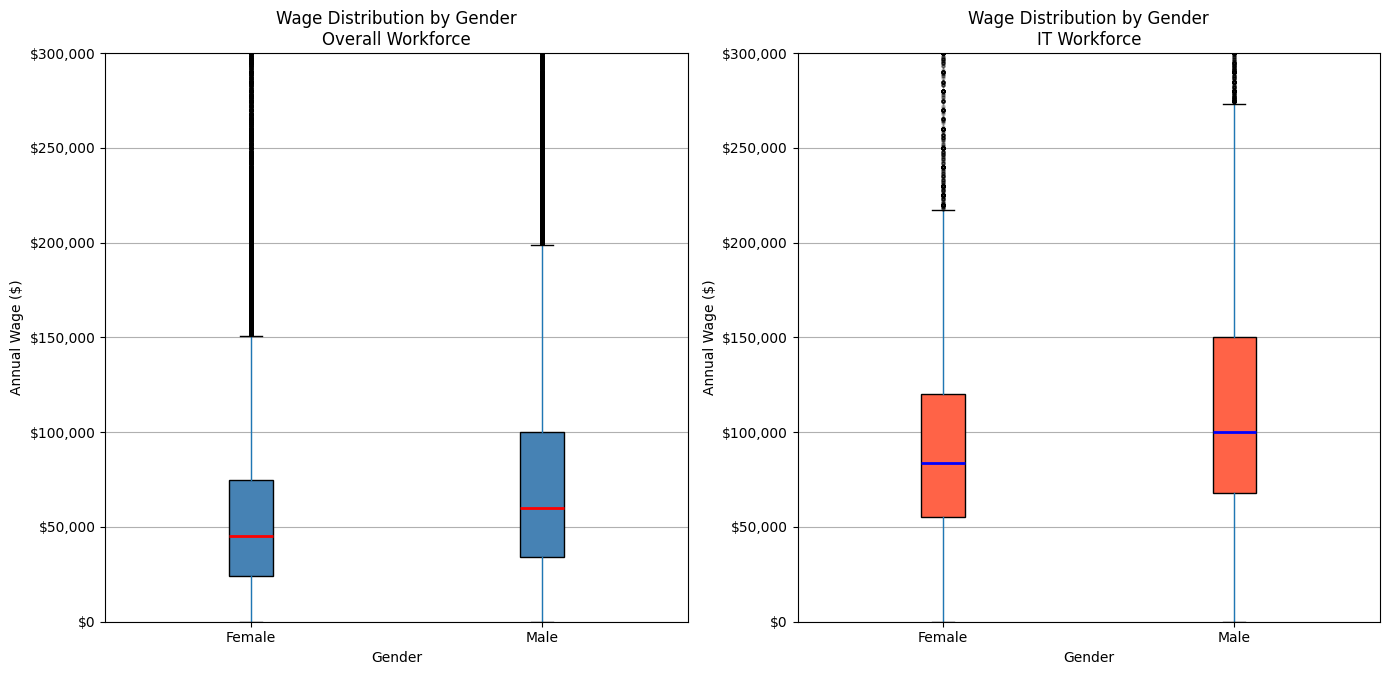

In [34]:
fig, axes = plt.subplots(1, 2, figsize=(14, 7))

# Box plot 1: Overall workforce wage distribution by gender
ipums_clean.boxplot(column='INCWAGE', by='SEX_LABEL', ax=axes[0],
                    patch_artist=True,
                    boxprops=dict(facecolor='steelblue', color='black'),
                    medianprops=dict(color='red', linewidth=2),
                    flierprops=dict(marker='o', markersize=2, alpha=0.3))

axes[0].set_title('Wage Distribution by Gender\nOverall Workforce', fontsize=12)
axes[0].set_xlabel('Gender')
axes[0].set_ylabel('Annual Wage ($)')
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
axes[0].set_ylim(0, 300000)

# Box plot 2: IT workforce wage distribution by gender
ipums_it.boxplot(column='INCWAGE', by='SEX_LABEL', ax=axes[1],
                 patch_artist=True,
                 boxprops=dict(facecolor='tomato', color='black'),
                 medianprops=dict(color='blue', linewidth=2),
                 flierprops=dict(marker='o', markersize=2, alpha=0.3))

axes[1].set_title('Wage Distribution by Gender\nIT Workforce', fontsize=12)
axes[1].set_xlabel('Gender')
axes[1].set_ylabel('Annual Wage ($)')
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'${x:,.0f}'))
axes[1].set_ylim(0, 300000)

plt.suptitle('')
plt.tight_layout()
plt.show()